# 08d — ProteinMPNN Candidate Structural Validation

## Pipeline 4 — Structural validation of AI-derived peptide candidates

This notebook takes the 5 new candidates selected in `08c` and subjects them
to the same structural logic used previously for CLEAR candidates.

Input shortlist:

```text
MPNN_NEW_01  TGPRNQYRDLP
MPNN_NEW_02  IGPRNQYRDLG
MPNN_NEW_03  PGPRNQYRDLP
MPNN_NEW_04  IGPRNQYRDLN
MPNN_NEW_05  IGPRHQYRDLP
```

Established references:

```text
F0010 = IGERCQYRDLK
CF06  = IGERCQYRELR
CF02  = IGERSQYRELK
```

---

## Workflow

```text
08c shortlist
   ↓
map mutations vs F0010
   ↓
FoldX BuildModel
   ↓
FoldX AnalyseComplex
   ↓
FoldX ranking
   ↓
FlexPepDock refinement
   ↓
Rosetta ranking
   ↓
integrated structural shortlist
```

---

## Interpretation

FoldX and Rosetta are used here as **computational structural filters**.

They do not provide experimental evidence and should not be interpreted as
absolute binding free energies.

The purpose is to determine whether the ProteinMPNN designs survive the same
type of downstream structural scrutiny previously applied to the CLEAR
candidates.
### EXECUTE in Kernel (PEARL AI)

## 1. Imports and environment

In [1]:
import os
import re
import sys
import json
import math
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 250)

print("Python:", sys.version)
print("Working directory:", Path.cwd())


Python: 3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:29:05) [Clang 19.1.7 ]
Working directory: /Users/robertobruzzese/Desktop/venv


## 2. Configuration

In [2]:
# ------------------------------------------------------
# Input from 08c
# ------------------------------------------------------
SHORTLIST_CSV = (
    Path("outputs")
    / "pipeline_4_ai_08c_integrated_candidate_selection"
    / "tables"
    / "08c_candidates_for_structural_validation.csv"
)

# ------------------------------------------------------
# F0010 native/bound reference structure
# ------------------------------------------------------
F0010_COMPLEX_PDB = (
    Path("outputs")
    / "clear_local_peptide_dataset_04c"
    / "foldx_buildmodel"
    / "F0010_native_complex.pdb"
)

RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"

F0010_SEQUENCE = "IGERCQYRDLK"

# F0010 corresponds to chain-D residues 38–48.
F0010_START_RESSEQ = 38
F0010_END_RESSEQ = 48

# ------------------------------------------------------
# Established references
# ------------------------------------------------------
REFERENCE_SEQUENCES = {
    "F0010": "IGERCQYRDLK",
    "CF06": "IGERCQYRELR",
    "CF02": "IGERSQYRELK",
}

# Existing best Rosetta poses, if available.
REFERENCE_ROSETTA_PDBS = {
    "CF06": (
        Path("outputs")
        / "clear_counterfactual_flexpepdock_05d"
        / "best_poses"
        / "CF_06_best.pdb"
    ),
    "CF02": (
        Path("outputs")
        / "clear_counterfactual_flexpepdock_05d"
        / "best_poses"
        / "CF_02_best.pdb"
    ),
}

# ------------------------------------------------------
# FoldX
# ------------------------------------------------------
FOLDX_EXPLICIT_PATH = Path(
    "/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231"
)
# Example if needed:
# FOLDX_EXPLICIT_PATH = Path("/absolute/path/to/foldx")

FOLDX_RUN_AUTOMATICALLY = False

# ------------------------------------------------------
# Rosetta FlexPepDock
# ------------------------------------------------------
ROSETTA_FLEXPEPDOCK_EXPLICIT_PATH = None
ROSETTA_DATABASE_EXPLICIT_PATH = None

# Known PEARL Mac installation can be auto-detected from Downloads.
ROSETTA_SEARCH_ROOTS = [
    Path.home() / "Downloads",
    Path.home(),
]

ROSETTA_NSTRUCT = 20
ROSETTA_RUN_AUTOMATICALLY = False

# Set True first if you only want to verify command generation.
ROSETTA_FAST_TEST = False

if ROSETTA_FAST_TEST:
    ROSETTA_NSTRUCT = 2

# ------------------------------------------------------
# Selection
# ------------------------------------------------------
TOP_N_FOLDX_FOR_ROSETTA = 5

# ------------------------------------------------------
# Output
# ------------------------------------------------------
OUTPUT_ROOT = (
    Path("outputs")
    / "pipeline_4_ai_08d_structural_validation"
)

INPUT_DIR = OUTPUT_ROOT / "input"
FOLDX_DIR = OUTPUT_ROOT / "foldx"
FOLDX_BUILD_DIR = FOLDX_DIR / "buildmodel"
FOLDX_ANALYSE_DIR = FOLDX_DIR / "analysecomplex"
ROSETTA_DIR = OUTPUT_ROOT / "rosetta"
ROSETTA_INPUT_DIR = ROSETTA_DIR / "inputs"
ROSETTA_OUTPUT_DIR = ROSETTA_DIR / "outputs"
TABLE_DIR = OUTPUT_ROOT / "tables"
SCRIPT_DIR = OUTPUT_ROOT / "scripts"
REPORT_DIR = OUTPUT_ROOT / "reports"

for d in [
    OUTPUT_ROOT,
    INPUT_DIR,
    FOLDX_DIR,
    FOLDX_BUILD_DIR,
    FOLDX_ANALYSE_DIR,
    ROSETTA_DIR,
    ROSETTA_INPUT_DIR,
    ROSETTA_OUTPUT_DIR,
    TABLE_DIR,
    SCRIPT_DIR,
    REPORT_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("Shortlist:", SHORTLIST_CSV)
print("F0010 complex:", F0010_COMPLEX_PDB)
print("Output:", OUTPUT_ROOT.resolve())


Shortlist: outputs/pipeline_4_ai_08c_integrated_candidate_selection/tables/08c_candidates_for_structural_validation.csv
F0010 complex: outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/F0010_native_complex.pdb
Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation


## 3. Load 08c shortlist

In [3]:
if not SHORTLIST_CSV.exists():
    raise FileNotFoundError(
        f"08c shortlist not found: {SHORTLIST_CSV}"
    )

shortlist_df = pd.read_csv(SHORTLIST_CSV)

required_cols = [
    "candidate_id",
    "peptide_sequence",
]

missing = [
    c for c in required_cols
    if c not in shortlist_df.columns
]

if missing:
    raise RuntimeError(
        f"Missing columns in 08c shortlist: {missing}"
    )

print("08c candidates:", len(shortlist_df))

display(
    shortlist_df[
        [c for c in [
            "candidate_id",
            "peptide_sequence",
            "mutations_vs_F0010",
            "hamming_vs_F0010_recalc",
            "AI_integrated_score",
            "ESM2_PLL_mean",
            "best_ProteinMPNN_score",
            "sample_count",
        ] if c in shortlist_df.columns]
    ]
)


08c candidates: 5


,candidate_id,peptide_sequence,mutations_vs_F0010,hamming_vs_F0010_recalc,AI_integrated_score,ESM2_PLL_mean,best_ProteinMPNN_score,sample_count
0,MPNN_NEW_01,TGPRNQYRDLP,I1T+E3P+C5N+K11P,4,0.601249,-3.172003,1.2473,34
1,MPNN_NEW_02,IGPRNQYRDLG,E3P+C5N+K11G,3,0.551163,-3.171983,1.3662,1
2,MPNN_NEW_03,PGPRNQYRDLP,I1P+E3P+C5N+K11P,4,0.401600,-3.118172,1.4235,1
3,MPNN_NEW_04,IGPRNQYRDLN,E3P+C5N+K11N,3,0.514333,-3.193722,1.3458,2
4,MPNN_NEW_05,IGPRHQYRDLP,E3P+C5H+K11P,3,0.508830,-3.174593,1.4079,1


## 4. Validate F0010 structure and residue numbering

In [4]:
if not F0010_COMPLEX_PDB.exists():
    raise FileNotFoundError(
        f"F0010 complex not found: {F0010_COMPLEX_PDB}"
    )

THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
    "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
    "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S",
    "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}

def get_chain_residues(pdb_path, chain_id):
    residues = []
    seen = set()

    with open(
        pdb_path,
        "r",
        encoding="utf-8",
        errors="ignore",
    ) as handle:
        for line in handle:
            if not line.startswith("ATOM"):
                continue

            chain = line[21].strip()
            if chain != chain_id:
                continue

            resname = line[17:20].strip()
            resseq = int(line[22:26].strip())
            icode = line[26].strip()

            key = (chain, resseq, icode)

            if key in seen:
                continue

            seen.add(key)

            if resname in THREE_TO_ONE:
                residues.append({
                    "chain": chain,
                    "resseq": resseq,
                    "icode": icode,
                    "resname3": resname,
                    "aa": THREE_TO_ONE[resname],
                })

    return pd.DataFrame(residues)

d_residues = get_chain_residues(
    F0010_COMPLEX_PDB,
    PEPTIDE_CHAIN,
)

f0010_residue_df = (
    d_residues[
        (d_residues["resseq"] >= F0010_START_RESSEQ)
        & (d_residues["resseq"] <= F0010_END_RESSEQ)
    ]
    .copy()
    .reset_index(drop=True)
)

observed_f0010 = "".join(
    f0010_residue_df["aa"].tolist()
)

print("Observed F0010:", observed_f0010)
display(f0010_residue_df)

if observed_f0010 != F0010_SEQUENCE:
    raise RuntimeError(
        "F0010 sequence/numbering mismatch.\n"
        f"Expected: {F0010_SEQUENCE}\n"
        f"Observed: {observed_f0010}"
    )

print("F0010 numbering check: PASS")


Observed F0010: IGERCQYRDLK


,chain,resseq,icode,resname3,aa
0,D,38,,ILE,I
1,D,39,,GLY,G
2,D,40,,GLU,E
3,D,41,,ARG,R
4,D,42,,CYS,C
5,D,43,,GLN,Q
6,D,44,,TYR,Y
7,D,45,,ARG,R
8,D,46,,ASP,D
9,D,47,,LEU,L


F0010 numbering check: PASS


## 5. Map each ProteinMPNN sequence to FoldX mutations

In [5]:
ONE_TO_THREE = {
    v: k for k, v in THREE_TO_ONE.items()
}

def mutation_records(reference, sequence):
    if len(reference) != len(sequence):
        raise ValueError("Sequence lengths differ.")

    records = []

    for i, (old, new) in enumerate(
        zip(reference, sequence),
        start=1,
    ):
        if old == new:
            continue

        resseq = (
            F0010_START_RESSEQ
            + i - 1
        )

        records.append({
            "position": i,
            "old_aa": old,
            "new_aa": new,
            "resseq": resseq,
            "chain": PEPTIDE_CHAIN,
            "mutation_short": (
                f"{old}{i}{new}"
            ),
            # FoldX individual_list syntax:
            # original AA + chain + residue number + mutant AA
            "foldx_mutation": (
                f"{old}{PEPTIDE_CHAIN}{resseq}{new}"
            ),
        })

    return records

mutation_rows = []

for _, row in shortlist_df.iterrows():
    recs = mutation_records(
        F0010_SEQUENCE,
        row["peptide_sequence"],
    )

    for rec in recs:
        mutation_rows.append({
            "candidate_id": row["candidate_id"],
            "peptide_sequence": row["peptide_sequence"],
            **rec,
        })

mutation_df = pd.DataFrame(mutation_rows)

display(mutation_df)

mutation_df.to_csv(
    TABLE_DIR / "08d_candidate_mutation_map.csv",
    index=False,
)


,candidate_id,peptide_sequence,position,old_aa,new_aa,resseq,chain,mutation_short,foldx_mutation
0,MPNN_NEW_01,TGPRNQYRDLP,1,I,T,38,D,I1T,ID38T
1,MPNN_NEW_01,TGPRNQYRDLP,3,E,P,40,D,E3P,ED40P
2,MPNN_NEW_01,TGPRNQYRDLP,5,C,N,42,D,C5N,CD42N
3,MPNN_NEW_01,TGPRNQYRDLP,11,K,P,48,D,K11P,KD48P
4,MPNN_NEW_02,IGPRNQYRDLG,3,E,P,40,D,E3P,ED40P
5,MPNN_NEW_02,IGPRNQYRDLG,5,C,N,42,D,C5N,CD42N
6,MPNN_NEW_02,IGPRNQYRDLG,11,K,G,48,D,K11G,KD48G
7,MPNN_NEW_03,PGPRNQYRDLP,1,I,P,38,D,I1P,ID38P
8,MPNN_NEW_03,PGPRNQYRDLP,3,E,P,40,D,E3P,ED40P
9,MPNN_NEW_03,PGPRNQYRDLP,5,C,N,42,D,C5N,CD42N


## 6. Build FoldX `individual_list.txt`

Each ProteinMPNN candidate will be built independently from the same F0010
bound structure.

The mutation strings use F0010 chain-D numbering:

```text
position 1  → D38
...
position 11 → D48
```


In [6]:
candidate_mutation_strings = {}

for _, row in shortlist_df.iterrows():
    recs = mutation_records(
        F0010_SEQUENCE,
        row["peptide_sequence"],
    )

    mutation_string = ",".join(
        r["foldx_mutation"]
        for r in recs
    ) + ";"

    candidate_mutation_strings[
        row["candidate_id"]
    ] = mutation_string

mutation_string_df = pd.DataFrame([
    {
        "candidate_id": cid,
        "foldx_mutations": muts,
    }
    for cid, muts in candidate_mutation_strings.items()
])

display(mutation_string_df)

mutation_string_df.to_csv(
    TABLE_DIR / "08d_FoldX_mutation_strings.csv",
    index=False,
)


,candidate_id,foldx_mutations
0,MPNN_NEW_01,"ID38T,ED40P,CD42N,KD48P;"
1,MPNN_NEW_02,"ED40P,CD42N,KD48G;"
2,MPNN_NEW_03,"ID38P,ED40P,CD42N,KD48P;"
3,MPNN_NEW_04,"ED40P,CD42N,KD48N;"
4,MPNN_NEW_05,"ED40P,CD42H,KD48P;"


## 7. Prepare FoldX input structure

In [7]:
FOLDX_INPUT_PDB = (
    FOLDX_BUILD_DIR
    / "F0010_native_complex.pdb"
)

shutil.copy2(
    F0010_COMPLEX_PDB,
    FOLDX_INPUT_PDB,
)

print("FoldX input:", FOLDX_INPUT_PDB.resolve())


FoldX input: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/foldx/buildmodel/F0010_native_complex.pdb


## 8. Detect FoldX executable

In [8]:
def detect_foldx():
    candidates = []

    if FOLDX_EXPLICIT_PATH is not None:
        candidates.append(
            Path(FOLDX_EXPLICIT_PATH)
        )

    which = shutil.which("foldx")
    if which:
        candidates.append(
            Path(which)
        )

    # Common PEARL/manual locations.
    candidates.extend([
        Path.home() / "Downloads" / "foldx",
        Path.home() / "Downloads" / "FoldX" / "foldx",
        Path.cwd() / "foldx",
    ])

    for path in candidates:
        try:
            if path.exists() and os.access(path, os.X_OK):
                return path.resolve()
        except Exception:
            pass

    return None

FOLDX_EXE = detect_foldx()

print("Detected FoldX:", FOLDX_EXE)
print(
    "Automatic execution:",
    bool(FOLDX_EXE and FOLDX_RUN_AUTOMATICALLY)
)


Detected FoldX: /Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231
Automatic execution: False


## 9. Generate FoldX BuildModel script

The script builds one candidate at a time to keep candidate names and outputs
unambiguous.

If `FOLDX_RUN_AUTOMATICALLY=False`, run the generated shell script manually.


In [9]:
foldx_build_script = SCRIPT_DIR / "run_08d_foldx_buildmodel.sh"

script_lines = [
    "#!/bin/bash",
    "set -e",
    "",
    f'cd "{FOLDX_BUILD_DIR.resolve()}"',
    "",
]

foldx_cmd_name = (
    str(FOLDX_EXE)
    if FOLDX_EXE is not None
    else "foldx"
)

for _, row in shortlist_df.iterrows():
    cid = row["candidate_id"]
    muts = candidate_mutation_strings[cid]

    indiv_file = (
        FOLDX_BUILD_DIR
        / f"individual_list_{cid}.txt"
    )

    indiv_file.write_text(
        muts + "\n",
        encoding="utf-8",
    )

    candidate_out = (
        FOLDX_BUILD_DIR
        / cid
    )
    candidate_out.mkdir(
        parents=True,
        exist_ok=True,
    )

    script_lines.extend([
        f'echo "=== {cid} ==="',
        (
            f'"{foldx_cmd_name}" '
            f'--command=BuildModel '
            f'--pdb=F0010_native_complex.pdb '
            f'--mutant-file="{indiv_file.name}" '
            f'--output-dir="{candidate_out.resolve()}" '
            f'--numberOfRuns=1'
        ),
        "",
    ])

foldx_build_script.write_text(
    "\n".join(script_lines),
    encoding="utf-8",
)

os.chmod(
    foldx_build_script,
    0o755,
)

print(
    foldx_build_script.read_text(
        encoding="utf-8"
    )
)


#!/bin/bash
set -e

cd "/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/foldx/buildmodel"

echo "=== MPNN_NEW_01 ==="
"/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231" --command=BuildModel --pdb=F0010_native_complex.pdb --mutant-file="individual_list_MPNN_NEW_01.txt" --output-dir="/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/foldx/buildmodel/MPNN_NEW_01" --numberOfRuns=1

echo "=== MPNN_NEW_02 ==="
"/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231" --command=BuildModel --pdb=F0010_native_complex.pdb --mutant-file="individual_list_MPNN_NEW_02.txt" --output-dir="/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/foldx/buildmodel/MPNN_NEW_02" --numberOfRuns=1

echo "=== MPNN_NEW_03 ==="
"/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231" --command=BuildModel --pdb=F0010_native_complex.pdb --mutant-file="individual_lis

## 10. Optionally execute FoldX BuildModel

In [10]:
if FOLDX_EXE is not None and FOLDX_RUN_AUTOMATICALLY:
    result = subprocess.run(
        [str(foldx_build_script)],
        text=True,
        capture_output=True,
    )

    print(result.stdout)

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(
            "FoldX BuildModel execution failed."
        )
else:
    print(
        "FoldX BuildModel not executed automatically."
    )
    print(
        "Run from Terminal:"
    )
    print(
        foldx_build_script.resolve()
    )


FoldX BuildModel not executed automatically.
Run from Terminal:
/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/scripts/run_08d_foldx_buildmodel.sh


## 11. Locate FoldX-built candidate structures

In [11]:
def find_candidate_built_pdb(candidate_id):
    candidate_dir = (
        FOLDX_BUILD_DIR / candidate_id
    )

    pdbs = sorted(
        candidate_dir.glob("*.pdb")
    )

    # Exclude obvious input/reference names if present.
    pdbs = [
        p for p in pdbs
        if p.name != "F0010_native_complex.pdb"
    ]

    return pdbs[0] if pdbs else None

built_rows = []

for _, row in shortlist_df.iterrows():
    cid = row["candidate_id"]

    path = find_candidate_built_pdb(cid)

    built_rows.append({
        "candidate_id": cid,
        "peptide_sequence": row["peptide_sequence"],
        "built_pdb": str(path) if path else None,
        "build_present": path is not None,
    })

built_df = pd.DataFrame(built_rows)

display(built_df)

N_BUILT = int(
    built_df["build_present"].sum()
)

print(
    f"Built candidate structures found: "
    f"{N_BUILT}/{len(built_df)}"
)


,candidate_id,peptide_sequence,built_pdb,build_present
0,MPNN_NEW_01,TGPRNQYRDLP,outputs/pipeline_4_ai_08d_structural_validatio...,True
1,MPNN_NEW_02,IGPRNQYRDLG,outputs/pipeline_4_ai_08d_structural_validatio...,True
2,MPNN_NEW_03,PGPRNQYRDLP,outputs/pipeline_4_ai_08d_structural_validatio...,True
3,MPNN_NEW_04,IGPRNQYRDLN,outputs/pipeline_4_ai_08d_structural_validatio...,True
4,MPNN_NEW_05,IGPRHQYRDLP,outputs/pipeline_4_ai_08d_structural_validatio...,True


Built candidate structures found: 5/5


### If this cell shows `0/5`

That is expected if you have not yet run the FoldX shell script.

Run:

```bash
outputs/pipeline_4_ai_08d_structural_validation/scripts/run_08d_foldx_buildmodel.sh
```

then return here and rerun from **cell 11** onward.


## 12. Generate FoldX AnalyseComplex script

In [12]:
foldx_analyse_script = SCRIPT_DIR / "run_08d_foldx_analysecomplex.sh"

analyse_lines = [
    "#!/bin/bash",
    "set -e",
    "",
]

for _, row in built_df.iterrows():
    if not row["build_present"]:
        continue

    cid = row["candidate_id"]
    pdb_path = Path(row["built_pdb"])

    outdir = (
        FOLDX_ANALYSE_DIR / cid
    )
    outdir.mkdir(
        parents=True,
        exist_ok=True,
    )

    analyse_lines.extend([
        f'echo "=== {cid} ==="',
        (
            f'"{foldx_cmd_name}" '
            f'--command=AnalyseComplex '
            f'--pdb="{pdb_path.name}" '
            f'--pdb-dir="{pdb_path.parent.resolve()}" '
            f'--analyseComplexChains={RECEPTOR_CHAIN},{PEPTIDE_CHAIN} '
            f'--output-dir="{outdir.resolve()}"'
        ),
        "",
    ])

foldx_analyse_script.write_text(
    "\n".join(analyse_lines),
    encoding="utf-8",
)

os.chmod(
    foldx_analyse_script,
    0o755,
)

print(
    foldx_analyse_script.read_text(
        encoding="utf-8"
    )
)


#!/bin/bash
set -e

echo "=== MPNN_NEW_01 ==="
"/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231" --command=AnalyseComplex --pdb="F0010_native_complex_1.pdb" --pdb-dir="/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/foldx/buildmodel/MPNN_NEW_01" --analyseComplexChains=B,D --output-dir="/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/foldx/analysecomplex/MPNN_NEW_01"

echo "=== MPNN_NEW_02 ==="
"/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231" --command=AnalyseComplex --pdb="F0010_native_complex_1.pdb" --pdb-dir="/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/foldx/buildmodel/MPNN_NEW_02" --analyseComplexChains=B,D --output-dir="/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/foldx/analysecomplex/MPNN_NEW_02"

echo "=== MPNN_NEW_03 ==="
"/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_

## 13. Optionally execute FoldX AnalyseComplex

In [13]:
if (
    FOLDX_EXE is not None
    and FOLDX_RUN_AUTOMATICALLY
    and N_BUILT > 0
):
    result = subprocess.run(
        [str(foldx_analyse_script)],
        text=True,
        capture_output=True,
    )

    print(result.stdout)

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(
            "FoldX AnalyseComplex execution failed."
        )
else:
    print(
        "FoldX AnalyseComplex not executed automatically."
    )
    print(
        "After BuildModel succeeds, run:"
    )
    print(
        foldx_analyse_script.resolve()
    )


FoldX AnalyseComplex not executed automatically.
After BuildModel succeeds, run:
/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/scripts/run_08d_foldx_analysecomplex.sh


## 14. Parse FoldX interaction energies

In [14]:
def parse_foldx_interaction_energy(path):
    lines = path.read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines()

    header = None
    interaction_idx = None

    for line in lines:

        if not line.strip():
            continue

        parts = line.split("\t")

        # Trova la riga header
        if "Interaction Energy" in parts:
            header = parts
            interaction_idx = parts.index(
                "Interaction Energy"
            )
            continue

        # Prima riga dati successiva all'header
        if (
            header is not None
            and interaction_idx is not None
        ):
            if len(parts) > interaction_idx:

                try:
                    return float(
                        parts[interaction_idx]
                    )
                except ValueError:
                    continue

    return np.nan


foldx_energy_rows = []

for _, row in built_df.iterrows():

    cid = row["candidate_id"]

    outdir = (
        FOLDX_ANALYSE_DIR
        / cid
    )

    interaction_files = sorted(
        outdir.glob(
            "Interaction_*.fxout"
        )
    )

    if not interaction_files:

        foldx_energy_rows.append({
            "candidate_id": cid,
            "foldx_interaction_energy_kcal_mol": np.nan,
            "interaction_file": None,
        })

        continue

    path = interaction_files[0]

    energy = (
        parse_foldx_interaction_energy(
            path
        )
    )

    foldx_energy_rows.append({
        "candidate_id": cid,
        "foldx_interaction_energy_kcal_mol": energy,
        "interaction_file": str(path),
    })


foldx_energy_df = pd.DataFrame(
    foldx_energy_rows
)

foldx_energy_df = (
    foldx_energy_df.merge(
        shortlist_df[
            [
                "candidate_id",
                "peptide_sequence",
            ]
        ],
        on="candidate_id",
        how="left",
    )
)

display(
    foldx_energy_df.sort_values(
        "foldx_interaction_energy_kcal_mol",
        ascending=True,
    )
)

foldx_energy_df.to_csv(
    TABLE_DIR
    / "08d_FoldX_interaction_energy_summary.csv",
    index=False,
)

,candidate_id,foldx_interaction_energy_kcal_mol,interaction_file,peptide_sequence
4,MPNN_NEW_05,-13.74780,outputs/pipeline_4_ai_08d_structural_validatio...,IGPRHQYRDLP
1,MPNN_NEW_02,-12.70790,outputs/pipeline_4_ai_08d_structural_validatio...,IGPRNQYRDLG
0,MPNN_NEW_01,-11.74070,outputs/pipeline_4_ai_08d_structural_validatio...,TGPRNQYRDLP
3,MPNN_NEW_04,-11.30780,outputs/pipeline_4_ai_08d_structural_validatio...,IGPRNQYRDLN
2,MPNN_NEW_03,-9.44251,outputs/pipeline_4_ai_08d_structural_validatio...,PGPRNQYRDLP


## 15. FoldX ranking

In [15]:
foldx_rank_df = (
    foldx_energy_df[
        foldx_energy_df[
            "foldx_interaction_energy_kcal_mol"
        ].notna()
    ]
    .copy()
)

if len(foldx_rank_df):
    foldx_rank_df = (
        foldx_rank_df
        .sort_values(
            "foldx_interaction_energy_kcal_mol",
            ascending=True,
        )
        .reset_index(drop=True)
    )

    foldx_rank_df.insert(
        0,
        "foldx_rank",
        np.arange(
            len(foldx_rank_df)
        ) + 1,
    )

display(foldx_rank_df)

foldx_rank_df.to_csv(
    TABLE_DIR / "08d_FoldX_ranking.csv",
    index=False,
)


,foldx_rank,candidate_id,foldx_interaction_energy_kcal_mol,interaction_file,peptide_sequence
0,1,MPNN_NEW_05,-13.74780,outputs/pipeline_4_ai_08d_structural_validatio...,IGPRHQYRDLP
1,2,MPNN_NEW_02,-12.70790,outputs/pipeline_4_ai_08d_structural_validatio...,IGPRNQYRDLG
2,3,MPNN_NEW_01,-11.74070,outputs/pipeline_4_ai_08d_structural_validatio...,TGPRNQYRDLP
3,4,MPNN_NEW_04,-11.30780,outputs/pipeline_4_ai_08d_structural_validatio...,IGPRNQYRDLN
4,5,MPNN_NEW_03,-9.44251,outputs/pipeline_4_ai_08d_structural_validatio...,PGPRNQYRDLP


## 16. Select structures for Rosetta FlexPepDock

If FoldX energies are available, the top `TOP_N_FOLDX_FOR_ROSETTA` candidates
are selected.

If FoldX has not yet been run, the notebook cannot proceed meaningfully to
Rosetta and will only prepare the downstream logic.


In [16]:
if len(foldx_rank_df):
    rosetta_candidates_df = (
        foldx_rank_df
        .head(
            TOP_N_FOLDX_FOR_ROSETTA
        )
        .copy()
    )
else:
    rosetta_candidates_df = pd.DataFrame(
        columns=[
            "candidate_id",
            "peptide_sequence",
            "foldx_interaction_energy_kcal_mol",
        ]
    )

display(rosetta_candidates_df)

rosetta_candidates_df.to_csv(
    TABLE_DIR / "08d_candidates_selected_for_Rosetta.csv",
    index=False,
)


,foldx_rank,candidate_id,foldx_interaction_energy_kcal_mol,interaction_file,peptide_sequence
0,1,MPNN_NEW_05,-13.74780,outputs/pipeline_4_ai_08d_structural_validatio...,IGPRHQYRDLP
1,2,MPNN_NEW_02,-12.70790,outputs/pipeline_4_ai_08d_structural_validatio...,IGPRNQYRDLG
2,3,MPNN_NEW_01,-11.74070,outputs/pipeline_4_ai_08d_structural_validatio...,TGPRNQYRDLP
3,4,MPNN_NEW_04,-11.30780,outputs/pipeline_4_ai_08d_structural_validatio...,IGPRNQYRDLN
4,5,MPNN_NEW_03,-9.44251,outputs/pipeline_4_ai_08d_structural_validatio...,PGPRNQYRDLP


## 17. Prepare Rosetta input PDBs

In [17]:
rosetta_input_rows = []

for _, row in rosetta_candidates_df.iterrows():
    cid = row["candidate_id"]

    built_match = built_df[
        built_df["candidate_id"] == cid
    ]

    if built_match.empty:
        continue

    built_pdb = built_match.iloc[0][
        "built_pdb"
    ]

    if not built_pdb:
        continue

    src = Path(built_pdb)
    dst = (
        ROSETTA_INPUT_DIR
        / f"{cid}.pdb"
    )

    shutil.copy2(
        src,
        dst,
    )

    rosetta_input_rows.append({
        "candidate_id": cid,
        "peptide_sequence": row["peptide_sequence"],
        "rosetta_input_pdb": str(dst),
    })

rosetta_input_df = pd.DataFrame(
    rosetta_input_rows
)

display(rosetta_input_df)


,candidate_id,peptide_sequence,rosetta_input_pdb
0,MPNN_NEW_05,IGPRHQYRDLP,outputs/pipeline_4_ai_08d_structural_validatio...
1,MPNN_NEW_02,IGPRNQYRDLG,outputs/pipeline_4_ai_08d_structural_validatio...
2,MPNN_NEW_01,TGPRNQYRDLP,outputs/pipeline_4_ai_08d_structural_validatio...
3,MPNN_NEW_04,IGPRNQYRDLN,outputs/pipeline_4_ai_08d_structural_validatio...
4,MPNN_NEW_03,PGPRNQYRDLP,outputs/pipeline_4_ai_08d_structural_validatio...


## 18. Detect Rosetta FlexPepDock and database

In [18]:
def find_flexpepdock():
    candidates = []

    if ROSETTA_FLEXPEPDOCK_EXPLICIT_PATH is not None:
        candidates.append(
            Path(
                ROSETTA_FLEXPEPDOCK_EXPLICIT_PATH
            )
        )

    for root in ROSETTA_SEARCH_ROOTS:
        if not root.exists():
            continue

        patterns = [
            "**/FlexPepDocking.static.macosclangrelease",
            "**/FlexPepDocking.default.macosclangrelease",
            "**/FlexPepDocking.*.macosclangrelease",
        ]

        for pattern in patterns:
            candidates.extend(
                root.glob(pattern)
            )

    for p in candidates:
        if (
            p.exists()
            and os.access(p, os.X_OK)
        ):
            return p.resolve()

    return None

def find_rosetta_database(binary_path):
    if ROSETTA_DATABASE_EXPLICIT_PATH is not None:
        p = Path(
            ROSETTA_DATABASE_EXPLICIT_PATH
        )
        if p.exists():
            return p.resolve()

    if binary_path is None:
        return None

    # Walk upward looking for main/database or database.
    for parent in binary_path.parents:
        for candidate in [
            parent / "database",
            parent / "main" / "database",
        ]:
            if candidate.exists():
                return candidate.resolve()

    # Also search around Downloads.
    for root in ROSETTA_SEARCH_ROOTS:
        if not root.exists():
            continue

        matches = list(
            root.glob(
                "**/rosetta.binary*/main/database"
            )
        )

        if matches:
            return matches[0].resolve()

    return None

ROSETTA_FLEXPEPDOCK = find_flexpepdock()
ROSETTA_DATABASE = find_rosetta_database(
    ROSETTA_FLEXPEPDOCK
)

print(
    "Detected FlexPepDock:",
    ROSETTA_FLEXPEPDOCK,
)

print(
    "Rosetta database:",
    ROSETTA_DATABASE,
)

RUN_ROSETTA_FLEXPEPDOCK = bool(
    ROSETTA_FLEXPEPDOCK
    and ROSETTA_DATABASE
    and ROSETTA_RUN_AUTOMATICALLY
)

print(
    "RUN_ROSETTA_FLEXPEPDOCK:",
    RUN_ROSETTA_FLEXPEPDOCK,
)


Detected FlexPepDock: /Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/source/build/src/release/macos/12.7/64/arm/clang/14.0/static/FlexPepDocking.static.macosclangrelease
Rosetta database: /Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/database
RUN_ROSETTA_FLEXPEPDOCK: False


## 19. Generate FlexPepDock refinement script

In [19]:
rosetta_script = (
    SCRIPT_DIR
    / "run_08d_flexpepdock.sh"
)

rosetta_lines = [
    "#!/bin/bash",
    "set -e",
    "",
]

rosetta_binary_str = (
    str(ROSETTA_FLEXPEPDOCK)
    if ROSETTA_FLEXPEPDOCK
    else "/PATH/TO/FlexPepDocking.static.macosclangrelease"
)

rosetta_database_str = (
    str(ROSETTA_DATABASE)
    if ROSETTA_DATABASE
    else "/PATH/TO/rosetta/main/database"
)

for _, row in rosetta_input_df.iterrows():
    cid = row["candidate_id"]
    pdb_path = Path(
        row["rosetta_input_pdb"]
    )

    candidate_outdir = (
        ROSETTA_OUTPUT_DIR / cid
    )
    candidate_outdir.mkdir(
        parents=True,
        exist_ok=True,
    )

    scorefile = (
        candidate_outdir
        / f"{cid}_score.sc"
    )

    rosetta_lines.extend([
        f'echo "=== {cid} ==="',
        (
            f'"{rosetta_binary_str}" '
            f'-database "{rosetta_database_str}" '
            f'-s "{pdb_path.resolve()}" '
            f'-pep_refine '
            f'-ex1 '
            f'-ex2aro '
            f'-use_input_sc '
            f'-nstruct {ROSETTA_NSTRUCT} '
            f'-out:path:all "{candidate_outdir.resolve()}" '
            f'-out:file:scorefile "{scorefile.resolve()}" '
            f'-out:suffix _refined'
        ),
        "",
    ])

rosetta_script.write_text(
    "\n".join(rosetta_lines),
    encoding="utf-8",
)

os.chmod(
    rosetta_script,
    0o755,
)

print(
    rosetta_script.read_text(
        encoding="utf-8"
    )
)


#!/bin/bash
set -e

echo "=== MPNN_NEW_05 ==="
"/Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/source/build/src/release/macos/12.7/64/arm/clang/14.0/static/FlexPepDocking.static.macosclangrelease" -database "/Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/database" -s "/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/rosetta/inputs/MPNN_NEW_05.pdb" -pep_refine -ex1 -ex2aro -use_input_sc -nstruct 20 -out:path:all "/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/rosetta/outputs/MPNN_NEW_05" -out:file:scorefile "/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/rosetta/outputs/MPNN_NEW_05/MPNN_NEW_05_score.sc" -out:suffix _refined

echo "=== MPNN_NEW_02 ==="
"/Users/robertobruzzese/Downloads/rosetta.binary.m1.release-408/main/source/build/src/release/macos/12.7/64/arm/clang/14.0/static/FlexPepDocking.static.macosclangrelease" -database "/Users/r

## 20. Optionally execute FlexPepDock

In [20]:
if RUN_ROSETTA_FLEXPEPDOCK and len(rosetta_input_df):
    result = subprocess.run(
        [str(rosetta_script)],
        text=True,
        capture_output=True,
    )

    print(result.stdout)

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(
            "FlexPepDock execution failed."
        )
else:
    print(
        "FlexPepDock not executed automatically."
    )

    if len(rosetta_input_df):
        print(
            "Run from Terminal:"
        )
        print(
            rosetta_script.resolve()
        )
    else:
        print(
            "No Rosetta inputs yet. "
            "Complete FoldX first."
        )


FlexPepDock not executed automatically.
Run from Terminal:
/Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/scripts/run_08d_flexpepdock.sh


## 21. Parse Rosetta scorefiles

In [21]:
def parse_rosetta_scorefile(path):
    """
    Parse a Rosetta .sc scorefile into a pandas DataFrame.

    The function:
    - finds the SCORE header;
    - reads all SCORE data rows;
    - converts numeric columns safely;
    - keeps 'description' as text.
    """

    lines = path.read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines()

    header = None
    rows = []

    for line in lines:

        if not line.startswith("SCORE:"):
            continue

        parts = line.split()

        # Header row
        if "description" in parts:
            header = parts[1:]
            continue

        # Ignore data rows until a header has been found
        if header is None:
            continue

        values = parts[1:]

        # Skip malformed rows
        if len(values) != len(header):
            continue

        rows.append(
            dict(
                zip(
                    header,
                    values,
                )
            )
        )

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)

    # Convert all columns except description to numeric.
    # errors="coerce" is compatible with current pandas versions.
    for c in df.columns:
        if c != "description":
            df[c] = pd.to_numeric(
                df[c],
                errors="coerce",
            )

    return df


rosetta_summary_rows = []

for _, row in rosetta_input_df.iterrows():

    cid = row["candidate_id"]

    candidate_outdir = (
        ROSETTA_OUTPUT_DIR
        / cid
    )

    scorefiles = sorted(
        candidate_outdir.glob("*.sc")
    )

    # --------------------------------------------------
    # No scorefile found
    # --------------------------------------------------
    if not scorefiles:

        rosetta_summary_rows.append({
            "candidate_id": cid,
            "best_total_score": np.nan,
            "best_I_sc": np.nan,
            "best_description": None,
            "scorefile": None,
        })

        continue

    scorefile = scorefiles[0]

    print(
        f"Parsing {cid}: {scorefile.name}"
    )

    sdf = parse_rosetta_scorefile(
        scorefile
    )

    # --------------------------------------------------
    # Empty/unreadable scorefile
    # --------------------------------------------------
    if sdf.empty:

        rosetta_summary_rows.append({
            "candidate_id": cid,
            "best_total_score": np.nan,
            "best_I_sc": np.nan,
            "best_description": None,
            "scorefile": str(scorefile),
        })

        continue

    print(
        f"  decoys parsed: {len(sdf)}"
    )

    print(
        f"  columns: {list(sdf.columns)}"
    )

    # --------------------------------------------------
    # Select ranking metric
    #
    # Prefer I_sc, because it is the Rosetta
    # interface score.
    # Otherwise fall back to total_score.
    # --------------------------------------------------
    if (
        "I_sc" in sdf.columns
        and sdf["I_sc"].notna().any()
    ):
        metric_col = "I_sc"

    elif (
        "total_score" in sdf.columns
        and sdf["total_score"].notna().any()
    ):
        metric_col = "total_score"

    else:

        rosetta_summary_rows.append({
            "candidate_id": cid,
            "best_total_score": np.nan,
            "best_I_sc": np.nan,
            "best_description": None,
            "scorefile": str(scorefile),
        })

        print(
            f"  WARNING: no usable I_sc or total_score for {cid}"
        )

        continue

    # --------------------------------------------------
    # Best Rosetta decoy
    # Lower score = better
    # --------------------------------------------------
    metric_values = pd.to_numeric(
        sdf[metric_col],
        errors="coerce",
    )

    valid_mask = metric_values.notna()

    if not valid_mask.any():

        rosetta_summary_rows.append({
            "candidate_id": cid,
            "best_total_score": np.nan,
            "best_I_sc": np.nan,
            "best_description": None,
            "scorefile": str(scorefile),
        })

        continue

    best_idx = metric_values[
        valid_mask
    ].idxmin()

    best = sdf.loc[
        best_idx
    ]

    best_total_score = (
        float(best["total_score"])
        if (
            "total_score" in sdf.columns
            and pd.notna(
                best["total_score"]
            )
        )
        else np.nan
    )

    best_I_sc = (
        float(best["I_sc"])
        if (
            "I_sc" in sdf.columns
            and pd.notna(
                best["I_sc"]
            )
        )
        else np.nan
    )

    best_description = (
        str(best["description"])
        if (
            "description" in sdf.columns
            and pd.notna(
                best["description"]
            )
        )
        else None
    )

    rosetta_summary_rows.append({
        "candidate_id": cid,
        "best_total_score": best_total_score,
        "best_I_sc": best_I_sc,
        "best_description": best_description,
        "scorefile": str(scorefile),
    })

    print(
        f"  best metric: {metric_col}"
    )

    print(
        f"  best total_score: {best_total_score}"
    )

    print(
        f"  best I_sc: {best_I_sc}"
    )

    print(
        f"  best decoy: {best_description}"
    )


# ------------------------------------------------------
# Build final summary table
# ------------------------------------------------------
rosetta_summary_df = pd.DataFrame(
    rosetta_summary_rows
)

if len(rosetta_summary_df):

    rosetta_summary_df = (
        rosetta_summary_df.merge(
            shortlist_df[
                [
                    "candidate_id",
                    "peptide_sequence",
                ]
            ],
            on="candidate_id",
            how="left",
        )
    )

    # Put useful columns first
    preferred_cols = [
        "candidate_id",
        "peptide_sequence",
        "best_total_score",
        "best_I_sc",
        "best_description",
        "scorefile",
    ]

    rosetta_summary_df = (
        rosetta_summary_df[
            [
                c
                for c in preferred_cols
                if c in rosetta_summary_df.columns
            ]
        ]
    )

# ------------------------------------------------------
# Display ranking
# ------------------------------------------------------
if (
    len(rosetta_summary_df)
    and rosetta_summary_df[
        "best_I_sc"
    ].notna().any()
):

    display(
        rosetta_summary_df.sort_values(
            "best_I_sc",
            ascending=True,
        )
    )

elif (
    len(rosetta_summary_df)
    and rosetta_summary_df[
        "best_total_score"
    ].notna().any()
):

    display(
        rosetta_summary_df.sort_values(
            "best_total_score",
            ascending=True,
        )
    )

else:

    display(
        rosetta_summary_df
    )

# ------------------------------------------------------
# Save
# ------------------------------------------------------
rosetta_summary_df.to_csv(
    TABLE_DIR
    / "08d_Rosetta_summary.csv",
    index=False,
)

print()
print(
    "Rosetta candidates parsed:",
    len(rosetta_summary_df)
)

print(
    "Valid I_sc values:",
    int(
        rosetta_summary_df[
            "best_I_sc"
        ].notna().sum()
    )
    if (
        len(rosetta_summary_df)
        and "best_I_sc"
        in rosetta_summary_df.columns
    )
    else 0
)

print(
    "Saved:",
    (
        TABLE_DIR
        / "08d_Rosetta_summary.csv"
    ).resolve()
)


Parsing MPNN_NEW_05: MPNN_NEW_05_score.sc
  decoys parsed: 20
  columns: ['total_score', 'I_bsa', 'I_hb', 'I_pack', 'I_sc', 'I_unsat', 'dslf_fa13', 'fa_atr', 'fa_dun', 'fa_elec', 'fa_intra_rep', 'fa_intra_sol_xover4', 'fa_rep', 'fa_sol', 'hbond_bb_sc', 'hbond_lr_bb', 'hbond_sc', 'hbond_sr_bb', 'lk_ball_wtd', 'omega', 'p_aa_pp', 'pep_sc', 'pep_sc_noref', 'pro_close', 'rama_prepro', 'ref', 'reweighted_sc', 'rmsALL', 'rmsALL_CAPRI_if', 'rmsALL_allIF', 'rmsALL_if', 'rmsBB', 'rmsBB_CAPRI_if', 'rmsBB_allIF', 'rmsBB_if', 'rmsCA', 'rmsCA_if', 'rmsSC_CAPRI_if', 'rmsSC_allIF', 'startRMSall', 'startRMSallif', 'startRMSbb', 'startRMSca', 'yhh_planarity', 'description']
  best metric: I_sc
  best total_score: 105.869
  best I_sc: -56.118
  best decoy: MPNN_NEW_05_refined_0015
Parsing MPNN_NEW_02: MPNN_NEW_02_score.sc
  decoys parsed: 20
  columns: ['total_score', 'I_bsa', 'I_hb', 'I_pack', 'I_sc', 'I_unsat', 'dslf_fa13', 'fa_atr', 'fa_dun', 'fa_elec', 'fa_intra_rep', 'fa_intra_sol_xover4', 'fa_rep'

,candidate_id,peptide_sequence,best_total_score,best_I_sc,best_description,scorefile
0,MPNN_NEW_05,IGPRHQYRDLP,105.869,-56.118,MPNN_NEW_05_refined_0015,outputs/pipeline_4_ai_08d_structural_validatio...
2,MPNN_NEW_01,TGPRNQYRDLP,119.107,-54.169,MPNN_NEW_01_refined_0009,outputs/pipeline_4_ai_08d_structural_validatio...
3,MPNN_NEW_04,IGPRNQYRDLN,96.062,-53.920,MPNN_NEW_04_refined_0001,outputs/pipeline_4_ai_08d_structural_validatio...
1,MPNN_NEW_02,IGPRNQYRDLG,108.232,-53.354,MPNN_NEW_02_refined_0002,outputs/pipeline_4_ai_08d_structural_validatio...
4,MPNN_NEW_03,PGPRNQYRDLP,108.179,-51.556,MPNN_NEW_03_refined_0015,outputs/pipeline_4_ai_08d_structural_validatio...



Rosetta candidates parsed: 5
Valid I_sc values: 5
Saved: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08d_structural_validation/tables/08d_Rosetta_summary.csv


## 22. Integrated structural ranking

In [22]:
structural_df = shortlist_df[
    [
        c for c in [
            "candidate_id",
            "peptide_sequence",
            "AI_integrated_score",
            "ESM2_PLL_mean",
            "best_ProteinMPNN_score",
            "hamming_vs_F0010_recalc",
        ]
        if c in shortlist_df.columns
    ]
].copy()

structural_df = structural_df.merge(
    foldx_energy_df[
        [
            "candidate_id",
            "foldx_interaction_energy_kcal_mol",
        ]
    ],
    on="candidate_id",
    how="left",
)

if len(rosetta_summary_df):
    structural_df = structural_df.merge(
        rosetta_summary_df[
            [
                "candidate_id",
                "best_total_score",
                "best_I_sc",
                "best_description",
            ]
        ],
        on="candidate_id",
        how="left",
    )

# Descriptive ranks only.
if (
    "foldx_interaction_energy_kcal_mol"
    in structural_df.columns
):
    structural_df["FoldX_rank"] = (
        structural_df[
            "foldx_interaction_energy_kcal_mol"
        ]
        .rank(
            method="min",
            ascending=True,
        )
    )

if (
    "best_I_sc"
    in structural_df.columns
    and structural_df["best_I_sc"].notna().any()
):
    structural_df["Rosetta_rank"] = (
        structural_df[
            "best_I_sc"
        ]
        .rank(
            method="min",
            ascending=True,
        )
    )
elif (
    "best_total_score"
    in structural_df.columns
    and structural_df["best_total_score"].notna().any()
):
    structural_df["Rosetta_rank"] = (
        structural_df[
            "best_total_score"
        ]
        .rank(
            method="min",
            ascending=True,
        )
    )
else:
    structural_df["Rosetta_rank"] = np.nan

available_rank_cols = [
    c for c in [
        "FoldX_rank",
        "Rosetta_rank",
    ]
    if (
        c in structural_df.columns
        and structural_df[c].notna().any()
    )
]

if available_rank_cols:
    structural_df[
        "structural_rank_sum"
    ] = structural_df[
        available_rank_cols
    ].sum(
        axis=1,
        min_count=1,
    )

    structural_df = (
        structural_df
        .sort_values(
            "structural_rank_sum",
            ascending=True,
            na_position="last",
        )
        .reset_index(drop=True)
    )

    structural_df.insert(
        0,
        "structural_rank",
        np.arange(
            len(structural_df)
        ) + 1,
    )

display(structural_df)

structural_df.to_csv(
    TABLE_DIR / "08d_integrated_structural_ranking.csv",
    index=False,
)


,structural_rank,candidate_id,peptide_sequence,AI_integrated_score,ESM2_PLL_mean,best_ProteinMPNN_score,hamming_vs_F0010_recalc,foldx_interaction_energy_kcal_mol,best_total_score,best_I_sc,best_description,FoldX_rank,Rosetta_rank,structural_rank_sum
0,1,MPNN_NEW_05,IGPRHQYRDLP,0.508830,-3.174593,1.4079,3,-13.74780,105.869,-56.118,MPNN_NEW_05_refined_0015,1.0,1.0,2.0
1,2,MPNN_NEW_01,TGPRNQYRDLP,0.601249,-3.172003,1.2473,4,-11.74070,119.107,-54.169,MPNN_NEW_01_refined_0009,3.0,2.0,5.0
2,3,MPNN_NEW_02,IGPRNQYRDLG,0.551163,-3.171983,1.3662,3,-12.70790,108.232,-53.354,MPNN_NEW_02_refined_0002,2.0,4.0,6.0
3,4,MPNN_NEW_04,IGPRNQYRDLN,0.514333,-3.193722,1.3458,3,-11.30780,96.062,-53.920,MPNN_NEW_04_refined_0001,4.0,3.0,7.0
4,5,MPNN_NEW_03,PGPRNQYRDLP,0.401600,-3.118172,1.4235,4,-9.44251,108.179,-51.556,MPNN_NEW_03_refined_0015,5.0,5.0,10.0


## 23. Compare with established references

This section adds established reference values where they are already available
from previous PEARL stages.

It intentionally does not fabricate missing scores.

The new ProteinMPNN candidates should only be compared directly with the
references for metrics generated using equivalent protocols.


In [23]:
reference_rows = []

for cid, seq in REFERENCE_SEQUENCES.items():
    reference_rows.append({
        "candidate_id": cid,
        "peptide_sequence": seq,
        "source": "established_reference",
    })

reference_df = pd.DataFrame(
    reference_rows
)

new_df = shortlist_df[
    ["candidate_id", "peptide_sequence"]
].copy()

new_df["source"] = "ProteinMPNN_new"

comparison_identity_df = pd.concat(
    [
        reference_df,
        new_df,
    ],
    ignore_index=True,
)

display(comparison_identity_df)

comparison_identity_df.to_csv(
    TABLE_DIR / "08d_reference_and_new_candidate_identity.csv",
    index=False,
)


,candidate_id,peptide_sequence,source
0,F0010,IGERCQYRDLK,established_reference
1,CF06,IGERCQYRELR,established_reference
2,CF02,IGERSQYRELK,established_reference
3,MPNN_NEW_01,TGPRNQYRDLP,ProteinMPNN_new
4,MPNN_NEW_02,IGPRNQYRDLG,ProteinMPNN_new
5,MPNN_NEW_03,PGPRNQYRDLP,ProteinMPNN_new
6,MPNN_NEW_04,IGPRNQYRDLN,ProteinMPNN_new
7,MPNN_NEW_05,IGPRHQYRDLP,ProteinMPNN_new


## 24. Structural selection for possible MD

In [24]:
TOP_N_FOR_MD = 2

if (
    "structural_rank_sum"
    in structural_df.columns
    and structural_df[
        "structural_rank_sum"
    ].notna().any()
):
    md_candidates_df = (
        structural_df[
            structural_df[
                "structural_rank_sum"
            ].notna()
        ]
        .head(TOP_N_FOR_MD)
        .copy()
    )
else:
    md_candidates_df = pd.DataFrame()

display(md_candidates_df)

md_candidates_df.to_csv(
    TABLE_DIR / "08d_top_candidates_for_possible_MD.csv",
    index=False,
)


,structural_rank,candidate_id,peptide_sequence,AI_integrated_score,ESM2_PLL_mean,best_ProteinMPNN_score,hamming_vs_F0010_recalc,foldx_interaction_energy_kcal_mol,best_total_score,best_I_sc,best_description,FoldX_rank,Rosetta_rank,structural_rank_sum
0,1,MPNN_NEW_05,IGPRHQYRDLP,0.508830,-3.174593,1.4079,3,-13.7478,105.869,-56.118,MPNN_NEW_05_refined_0015,1.0,1.0,2.0
1,2,MPNN_NEW_01,TGPRNQYRDLP,0.601249,-3.172003,1.2473,4,-11.7407,119.107,-54.169,MPNN_NEW_01_refined_0009,3.0,2.0,5.0


## 25. QC

In [25]:
qc_rows = [
    {
        "check": "08c_shortlist_loaded",
        "pass": len(shortlist_df) > 0,
    },
    {
        "check": "F0010_sequence_numbering_valid",
        "pass": observed_f0010 == F0010_SEQUENCE,
    },
    {
        "check": "FoldX_mutation_map_generated",
        "pass": len(mutation_df) > 0,
    },
    {
        "check": "FoldX_build_script_generated",
        "pass": foldx_build_script.exists(),
    },
    {
        "check": "FoldX_analyse_script_generated",
        "pass": foldx_analyse_script.exists(),
    },
    {
        "check": "Rosetta_script_generated",
        "pass": rosetta_script.exists(),
    },
]

qc_df = pd.DataFrame(
    qc_rows
)

display(qc_df)

print(
    "Preparation QC passed:",
    bool(qc_df["pass"].all())
)

print(
    "Built structures:",
    N_BUILT,
    "/",
    len(shortlist_df),
)

print(
    "FoldX energies parsed:",
    int(
        foldx_energy_df[
            "foldx_interaction_energy_kcal_mol"
        ].notna().sum()
    ),
)

print(
    "Rosetta candidates parsed:",
    int(
        rosetta_summary_df[
            "best_I_sc"
        ].notna().sum()
        if (
            len(rosetta_summary_df)
            and "best_I_sc"
            in rosetta_summary_df.columns
        )
        else 0
    ),
)

qc_df.to_csv(
    TABLE_DIR / "08d_preparation_QC.csv",
    index=False,
)


,check,pass
0,08c_shortlist_loaded,True
1,F0010_sequence_numbering_valid,True
2,FoldX_mutation_map_generated,True
3,FoldX_build_script_generated,True
4,FoldX_analyse_script_generated,True
5,Rosetta_script_generated,True


Preparation QC passed: True
Built structures: 5 / 5
FoldX energies parsed: 5
Rosetta candidates parsed: 5


# 26. Execution workflow

This notebook is intentionally resumable.

## Phase A — preparation

Run from the beginning through the FoldX script-generation cells.

If FoldX is not detected automatically, run from Terminal:

```bash
outputs/pipeline_4_ai_08d_structural_validation/scripts/run_08d_foldx_buildmodel.sh
```

Then return to the notebook and rerun from:

```text
11. Locate FoldX-built candidate structures
```

Once all candidate structures are found, run:

```bash
outputs/pipeline_4_ai_08d_structural_validation/scripts/run_08d_foldx_analysecomplex.sh
```

Then rerun from:

```text
14. Parse FoldX interaction energies
```

---

## Phase B — Rosetta

After the FoldX ranking is available, the notebook prepares Rosetta inputs and
generates:

```bash
outputs/pipeline_4_ai_08d_structural_validation/scripts/run_08d_flexpepdock.sh
```

Run it from Terminal.

With:

```python
ROSETTA_NSTRUCT = 20
```

each candidate receives 20 FlexPepDock refinement decoys, matching the scale
used previously for CLEAR validation.

After Rosetta finishes, rerun from:

```text
21. Parse Rosetta scorefiles
```

---

## Phase C — decision

The final output of interest is:

```text
08d_integrated_structural_ranking.csv
```

and, if structural evidence is complete:

```text
08d_top_candidates_for_possible_MD.csv
```

Only the top 1–2 new ProteinMPNN candidates should then proceed to MD.


# 27. Scientific interpretation

Possible outcomes:

### A. ProteinMPNN candidate is strong in both FoldX and Rosetta

This provides useful **cross-method computational convergence** and supports
prioritization for subsequent MD analysis. It remains computational evidence
and does not establish experimental binding affinity or biological activity.

### B. ProteinMPNN candidate is strong in ESM-2/ProteinMPNN but weak in
FoldX/Rosetta

This suggests sequence/backbone plausibility did not translate into favorable
interface energetics after structural evaluation.

### C. ProteinMPNN and CLEAR leads remain different

That is scientifically informative. It would show that inverse folding and
counterfactual oracle optimization explore different regions of peptide
sequence space.

The final PEARL lead should therefore be selected by convergence across
multiple independent computational criteria, not by one AI model alone.


## Visualizzazioni molecolari 3D aggiunte
Queste celle sono state aggiunte per produrre figure strutturali più dettagliate con py3Dmol.

In [16]:
# Visualizzazione 3D ed esportazione del complesso NEW01
%pip install -q py3Dmol

from pathlib import Path
import py3Dmol
from IPython.display import HTML, display

# Cartella del notebook
CARTELLA = Path("/Users/robertobruzzese/Desktop/venv")
FILE_PNG = CARTELLA / "NEW01_struttura_3D.html"

def load_new_pdb(candidate):
    tag = candidate.replace("NEW", "NEW_")

    pdb_file = (
        CARTELLA
        / "outputs"
        / "pipeline_4_ai_08d_structural_validation"
        / "rosetta"
        / "inputs"
        / f"MPNN_{tag}.pdb"
    )

    if not pdb_file.exists():
        pdb_file = (
            CARTELLA
            / "outputs"
            / "pipeline_4_ai_08d_structural_validation"
            / "foldx"
            / "buildmodel"
            / f"MPNN_{tag}"
            / "WT_F0010_native_complex_1.pdb"
        )

    if not pdb_file.exists():
        raise FileNotFoundError(f"PDB non trovato: {pdb_file}")

    return pdb_file.read_text()

def show_complex(candidate="NEW01", width=1200, height=800):
    viewer = py3Dmol.view(width=width, height=height)

    viewer.addModel(load_new_pdb(candidate), "pdb")
    viewer.setBackgroundColor("white")

    # Recettore
    viewer.setStyle(
        {"chain": "B"},
        {"cartoon": {"color": "#B8B8B8", "opacity": 0.55}}
    )

    # Peptide
    viewer.setStyle(
        {"chain": "D"},
        {
            "cartoon": {"color": "#D62728"},
            "stick": {"color": "#D62728", "radius": 0.12}
        }
    )

    # Residui del recettore vicini al peptide
    viewer.addStyle(
        {
            "chain": "B",
            "within": {"distance": 4.0, "sel": {"chain": "D"}}
        },
        {"stick": {"color": "#F2A900", "radius": 0.14}}
    )

    viewer.center({"chain": "D"})
    viewer.zoomTo({"chain": "D"})
    viewer.zoom(1.8)
    viewer.rotate(20, "y")
    viewer.rotate(15, "x")

    return viewer

# Crea e mostra la struttura
viewer = show_complex("NEW01")
viewer.show()

# Esporta nella stessa cartella del notebook
html_code = viewer._make_html()
FILE_PNG.write_text(html_code, encoding="utf-8")

print("File salvato in:")
print(FILE_PNG)
print("Creato:", FILE_PNG.exists())
print("Dimensione:", FILE_PNG.stat().st_size, "byte")

Note: you may need to restart the kernel to use updated packages.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

File salvato in:
/Users/robertobruzzese/Desktop/venv/NEW01_struttura_3D.html
Creato: True
Dimensione: 329974 byte


In [33]:
from pathlib import Path
from pymol import cmd

pdb_file = (
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "pipeline_4_ai_08d_structural_validation/foldx/buildmodel/"
    "MPNN_NEW_01/WT_F0010_native_complex_1.pdb"
)

png_file = Path(
    "/Users/robertobruzzese/Desktop/venv/"
    "NEW01_struttura_3D_report.png"
)

cmd.reinitialize()
cmd.load(pdb_file, "complex")

cmd.hide("everything", "complex")

# Recettore: ribbon/cartoon trasparente
cmd.show("cartoon", "complex and chain B")
cmd.color("gray60", "complex and chain B")
cmd.set("cartoon_transparency", 35, "complex and chain B")

# Peptide
cmd.show("sticks", "complex and chain D")
cmd.color("red", "complex and chain D")

# Residui dell’interfaccia
cmd.select(
    "interface",
    "complex and chain B within 4 of complex and chain D"
)
cmd.show("sticks", "interface")
cmd.color("orange", "interface")

# Vista ravvicinata ma non eccessiva
cmd.orient("complex and chain D")
cmd.zoom("complex and chain D", 18)

cmd.bg_color("white")
cmd.set("ray_opaque_background", "off")

cmd.png(
    str(png_file),
    width=1600,
    height=1200,
    dpi=300,
    ray=1
)

print("PNG creato:", png_file)
print("Esiste:", png_file.exists())

PNG creato: /Users/robertobruzzese/Desktop/venv/NEW01_struttura_3D_report.png
Esiste: True


In [34]:
from pathlib import Path

cartelle = [
    Path("/Applications"),
    Path.home() / "Applications",
    Path.home() / "Downloads",
    Path.home() / "Desktop",
]

trovati = []

for cartella in cartelle:
    if cartella.exists():
        for elemento in cartella.rglob("ChimeraX.app"):
            trovati.append(elemento)

if trovati:
    for app in trovati:
        print("Trovato:", app)
        print("Eseguibile:", app / "Contents/MacOS/ChimeraX")
else:
    print("ChimeraX non trovato nelle cartelle controllate.")

ChimeraX non trovato nelle cartelle controllate.


In [35]:
import subprocess

risultato = subprocess.run(
    ["mdfind", "kMDItemFSName == 'ChimeraX-1.12.app'"],
    capture_output=True,
    text=True
)

print(risultato.stdout)

/Applications/ChimeraX-1.12.app



In [43]:
from pathlib import Path
import subprocess

chimerax = "/Applications/ChimeraX-1.12.app/Contents/MacOS/ChimeraX"

pdb_file = (
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "pipeline_4_ai_08d_structural_validation/foldx/buildmodel/"
    "MPNN_NEW_01/WT_F0010_native_complex_1.pdb"
)

png_file = Path(
    "/Users/robertobruzzese/Desktop/venv/NEW01_ChimeraX_3D.png"
)

script_file = Path(
    "/Users/robertobruzzese/Desktop/venv/render_NEW01.cxc"
)

script_file.write_text(f"""
open {pdb_file}
cartoon
select /B
color gray cartoons
transparency 35 cartoons
select /D
show atoms
color red atoms
view /D
save {png_file} width 1600 height 1200 supersample 3
exit
""")

subprocess.run(
    [chimerax, "--script", str(script_file)],
    check=True
)

print("PNG creato:")
print(png_file)
print("Esiste:", png_file.exists())

[49792:259:0828/190256.869154:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!
[49792:259:0828/190256.873431:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!


UCSF ChimeraX version: 1.12 (2026-06-12)
NOTE: © 2016-2026 Regents of the University of California.  All rights reserved.
NOTE: [How to cite UCSF ChimeraX](cxcmd:help help:credits.html)  

PNG creato:
/Users/robertobruzzese/Desktop/venv/NEW01_ChimeraX_3D.png
Esiste: True


In [60]:
from pathlib import Path
import subprocess

chimerax = "/Applications/ChimeraX-1.12.app/Contents/MacOS/ChimeraX"

pdb_file = (
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "pipeline_4_ai_08d_structural_validation/foldx/buildmodel/"
    "MPNN_NEW_01/WT_F0010_native_complex_1.pdb"
)

png_file = Path(
    "/Users/robertobruzzese/Desktop/venv/NEW01_ChimeraX_3D_final.png"
)

script_file = Path(
    "/Users/robertobruzzese/Desktop/venv/render_NEW01.cxc"
)

script_file.write_text(f"""
open {pdb_file}

cartoon
select /B

# Recettore beige
color cornsilk cartoons, /B
transparency 35 cartoons /B

select /D
show atoms
color red

select clear
set bgColor white

view /D
zoom /D 6

save {png_file} width 1600 height 1200 supersample 3
exit
""")

subprocess.run(
    [chimerax, "--script", str(script_file)],
    check=True
)

print("PNG creato:")
print(png_file)
print("Esiste:", png_file.exists())

[66501:259:0829/124956.520069:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!
[66501:259:0829/124956.520258:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!


PNG creato:
/Users/robertobruzzese/Desktop/venv/NEW01_ChimeraX_3D_final.png
Esiste: True


In [72]:
from pathlib import Path
import subprocess

chimerax = "/Applications/ChimeraX-1.12.app/Contents/MacOS/ChimeraX"

pdb_file = Path(
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "pipeline_4_ai_08d_structural_validation/foldx/buildmodel/"
    "MPNN_NEW_01/WT_F0010_native_complex_1.pdb"
)

png_file = Path(
    "/Users/robertobruzzese/Desktop/venv/"
    "NEW01_ChimeraX_3D_final.png"
)

script_file = Path(
    "/Users/robertobruzzese/Desktop/venv/render_NEW01.cxc"
)

script_file.write_text(f"""
open "{pdb_file}"

cartoon

# Recettore: catena B beige
color cornsilk /B target c
transparency 35 /B target c

# Peptide: catena D rosso
show atoms /D
color red /D target a

select clear
set bgColor black

view all
zoom 0.6

save "{png_file}" width 1600 height 1200 supersample 3
exit
""")

subprocess.run(
    [chimerax, "--script", str(script_file)],
    check=True
)

print("PNG creato:", png_file)
print("Esiste:", png_file.exists())

[66942:259:0829/130852.268608:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!
[66942:259:0829/130852.268775:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!


PNG creato: /Users/robertobruzzese/Desktop/venv/NEW01_ChimeraX_3D_final.png
Esiste: True


In [58]:
from pathlib import Path
import subprocess

chimerax = "/Applications/ChimeraX-1.12.app/Contents/MacOS/ChimeraX"

pdb_file = (
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "pipeline_4_ai_08d_structural_validation/foldx/buildmodel/"
    "MPNN_NEW_01/WT_F0010_native_complex_1.pdb"
)

png_file = Path(
    "/Users/robertobruzzese/Desktop/venv/NEW01_ChimeraX_3D_final.png"
)

script_file = Path(
    "/Users/robertobruzzese/Desktop/venv/render_NEW01.cxc"
)

script_file.write_text(f"""
open {pdb_file}

cartoon

color cartoons gray /B
transparency cartoons 35 /B

show atoms /D
color atoms red /D

select clear
set bgColor white

view all
zoom 0.6

save {png_file} width 1600 height 1200
exit
""")

subprocess.run(
    [chimerax, "--script", str(script_file)],
    check=True
)

print("PNG creato:")
print(png_file)
print("Esiste:", png_file.exists())

[66336:259:0829/124309.923294:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!
[66336:259:0829/124309.923459:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!


PNG creato:
/Users/robertobruzzese/Desktop/venv/NEW01_ChimeraX_3D_final.png
Esiste: True


In [53]:
from pathlib import Path
import subprocess

chimerax = "/Applications/ChimeraX-1.12.app/Contents/MacOS/ChimeraX"

pdb_file = (
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "pipeline_4_ai_08d_structural_validation/foldx/buildmodel/"
    "MPNN_NEW_01/WT_F0010_native_complex_1.pdb"
)

png_file = Path(
    "/Users/robertobruzzese/Desktop/venv/NEW01_ChimeraX_3D_final.png"
)

script_file = Path(
    "/Users/robertobruzzese/Desktop/venv/render_NEW01.cxc"
)

script_file.write_text(f"""
open {pdb_file}

cartoon

select /B
color sel gray
transparency 35 cartoons

select /D
show atoms
color sel red

select clear
set bgColor white

view all
save {png_file} width 1600 height 1200
exit
""")

subprocess.run(
    [chimerax, "--script", str(script_file)],
    check=True
)

print("PNG creato:")
print(png_file)
print("Esiste:", png_file.exists())

[61045:259:0829/084645.903743:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!
[61045:259:0829/084645.903918:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!


UCSF ChimeraX version: 1.12 (2026-06-12)
NOTE: © 2016-2026 Regents of the University of California.  All rights reserved.
NOTE: [How to cite UCSF ChimeraX](cxcmd:help help:credits.html)  

PNG creato:
/Users/robertobruzzese/Desktop/venv/NEW01_ChimeraX_3D_final.png
Esiste: True


In [57]:
from pathlib import Path
import subprocess

chimerax = "/Applications/ChimeraX-1.12.app/Contents/MacOS/ChimeraX"

pdb_file = (
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "pipeline_4_ai_08d_structural_validation/foldx/buildmodel/"
    "MPNN_NEW_01/WT_F0010_native_complex_1.pdb"
)

png_file = Path(
    "/Users/robertobruzzese/Desktop/venv/"
    "NEW01_ChimeraX_3D_final.png"
)

script_file = Path(
    "/Users/robertobruzzese/Desktop/venv/"
    "render_NEW01.cxc"
)

script_file.write_text(f"""
open {pdb_file}

cartoon
color bychain

select /D
show atoms

select clear
set bgColor white

view all
save {png_file} width 1600 height 1200
exit
""")

subprocess.run(
    [chimerax, "--script", str(script_file)],
    check=True
)

print("PNG creato:")
print(png_file)
print("Esiste:", png_file.exists())

[66332:259:0829/124259.663886:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!
[66332:259:0829/124259.664068:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!


UCSF ChimeraX version: 1.12 (2026-06-12)
NOTE: © 2016-2026 Regents of the University of California.  All rights reserved.
NOTE: [How to cite UCSF ChimeraX](cxcmd:help help:credits.html)  

PNG creato:
/Users/robertobruzzese/Desktop/venv/NEW01_ChimeraX_3D_final.png
Esiste: True


In [56]:
from pathlib import Path
import subprocess

chimerax = "/Applications/ChimeraX-1.12.app/Contents/MacOS/ChimeraX"

pdb_file = (
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "pipeline_3_md_07d_selected_peptide_comparison/"
    "production_1ns/F0010/structures/F0010_BD_cleaned.pdb"
)

png_file = Path(
    "/Users/robertobruzzese/Desktop/venv/F0010_struttura_3D.png"
)

script_file = Path(
    "/Users/robertobruzzese/Desktop/venv/render_F0010.cxc"
)

script_file.write_text(f"""
open {pdb_file}
cartoon
color bychain

select /D
show atoms
select clear

set bgColor white
view all
save {png_file} width 1600 height 1200
exit
""")

subprocess.run(
    [chimerax, "--script", str(script_file)],
    check=True
)

print("PNG creato:")
print(png_file)
print("Esiste:", png_file.exists())

[66314:259:0829/124215.355455:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!
[66314:259:0829/124215.355623:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!


UCSF ChimeraX version: 1.12 (2026-06-12)
NOTE: © 2016-2026 Regents of the University of California.  All rights reserved.
NOTE: [How to cite UCSF ChimeraX](cxcmd:help help:credits.html)  

PNG creato:
/Users/robertobruzzese/Desktop/venv/F0010_struttura_3D.png
Esiste: True


In [55]:
from pathlib import Path
import subprocess

chimerax = "/Applications/ChimeraX-1.12.app/Contents/MacOS/ChimeraX"

base = Path(
    "/Users/robertobruzzese/Desktop/venv/outputs/"
    "pipeline_3_md_07d_selected_peptide_comparison/"
    "production_1ns"
)

for nome in ["CF02", "CF06"]:
    pdb_file = base / nome / "structures" / f"{nome}_BD_cleaned.pdb"
    png_file = Path(
        f"/Users/robertobruzzese/Desktop/venv/{nome}_struttura_3D.png"
    )
    script_file = Path(
        f"/Users/robertobruzzese/Desktop/venv/render_{nome}.cxc"
    )

    script_file.write_text(f"""
open {pdb_file}
cartoon
color bychain

select /D
show atoms
select clear

set bgColor white
view all
save {png_file} width 1600 height 1200
exit
""")

    subprocess.run(
        [chimerax, "--script", str(script_file)],
        check=True
    )

    print(f"{nome}: {png_file}")
    print("Creato:", png_file.exists())

[61722:259:0829/091555.309176:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!
[61722:259:0829/091555.309357:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!


UCSF ChimeraX version: 1.12 (2026-06-12)
NOTE: © 2016-2026 Regents of the University of California.  All rights reserved.
NOTE: [How to cite UCSF ChimeraX](cxcmd:help help:credits.html)  

CF02: /Users/robertobruzzese/Desktop/venv/CF02_struttura_3D.png
Creato: True


[61725:259:0829/091556.740226:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!
[61725:259:0829/091556.740391:ERROR:service_utils.cc(339)] Skia Graphite backend = "" not found - falling back to Ganesh!


UCSF ChimeraX version: 1.12 (2026-06-12)
NOTE: © 2016-2026 Regents of the University of California.  All rights reserved.
NOTE: [How to cite UCSF ChimeraX](cxcmd:help help:credits.html)  

CF06: /Users/robertobruzzese/Desktop/venv/CF06_struttura_3D.png
Creato: True


Dati reali caricati correttamente:
F0010: RMSD=500 righe, RMSF=625 righe, contatti=81 righe
CF02: RMSD=500 righe, RMSF=625 righe, contatti=70 righe
CF06: RMSD=500 righe, RMSF=625 righe, contatti=88 righe


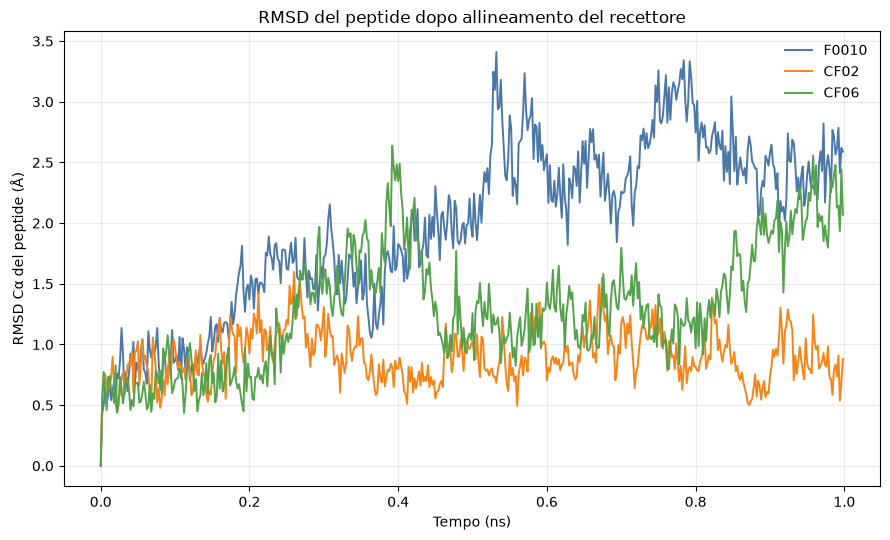

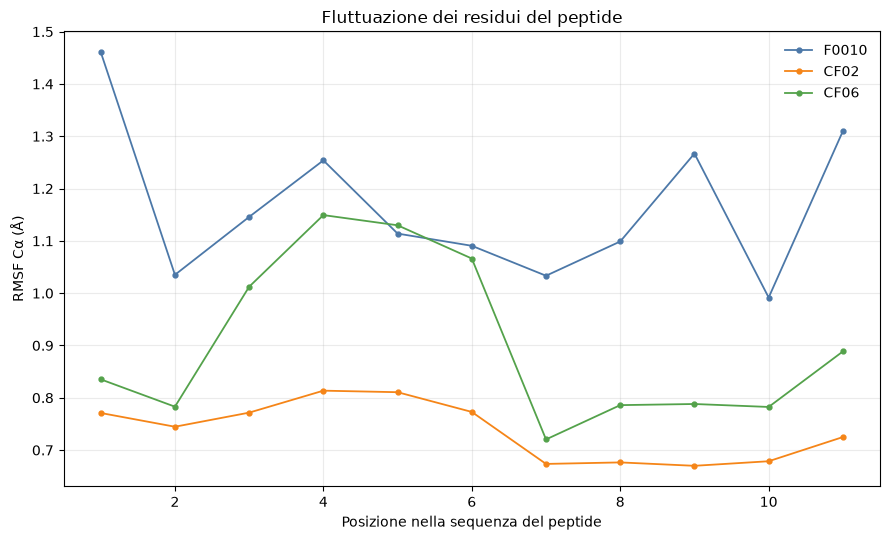

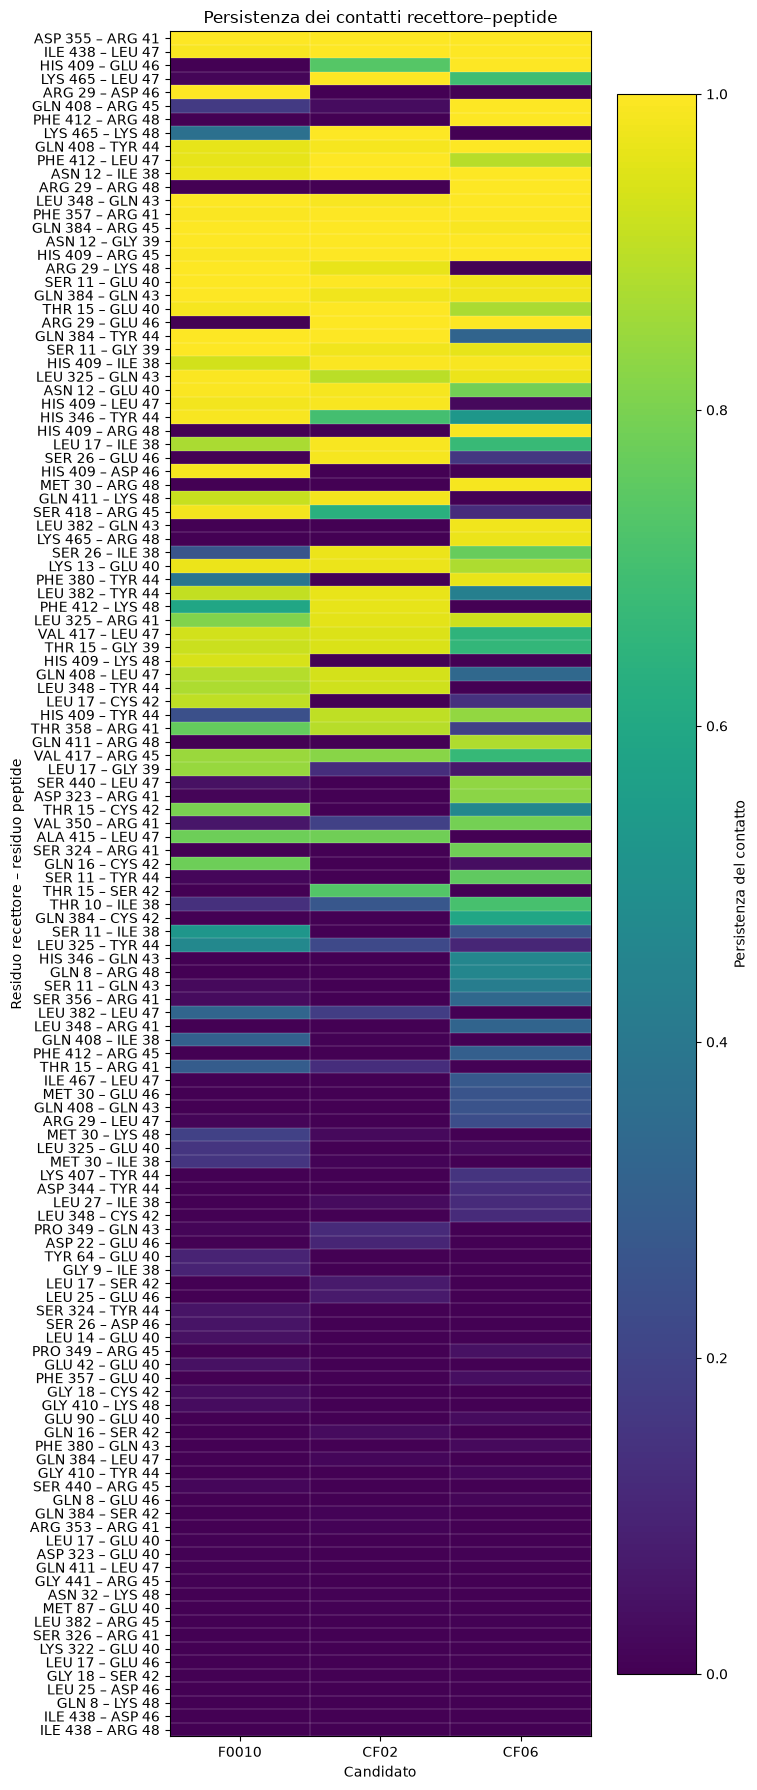


Figure salvate nella cartella:
/Users/robertobruzzese/Desktop/venv/figures_real_data


In [77]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Configurazione
# ============================================================

CANDIDATES = ["F0010", "CF02", "CF06"]
PEPTIDE_CHAIN = "D"

# Cerca dalla directory di lavoro del notebook.
# Se necessario, sostituisci Path.cwd() con il percorso della cartella outputs.
SEARCH_ROOT = Path.cwd()

# Preferisce gli output production_1ns rispetto ai test da 50 ps.
contact_files = list(
    SEARCH_ROOT.rglob("BD_contact_persistence.csv")
)

production_files = [
    p for p in contact_files
    if "production_1ns" in str(p)
]

if production_files:
    contact_files = production_files

if not contact_files:
    raise FileNotFoundError(
        "Nessun BD_contact_persistence.csv trovato. "
        "Controlla SEARCH_ROOT."
    )

# ============================================================
# Individuazione e caricamento dei CSV reali
# ============================================================

analysis_results = {}

for candidate in CANDIDATES:

    candidate_files = [
        p for p in contact_files
        if candidate.lower() in str(p).lower()
    ]

    if len(candidate_files) != 1:
        raise RuntimeError(
            f"Per {candidate} sono stati trovati "
            f"{len(candidate_files)} file:\n{candidate_files}\n"
            "Verifica il percorso degli output."
        )

    contact_path = candidate_files[0]
    analysis_dir = contact_path.parent

    rmsd_path = analysis_dir / "rmsd_timeseries.csv"
    rmsf_path = analysis_dir / "rmsf_by_residue.csv"

    missing = [
        str(path)
        for path in [rmsd_path, rmsf_path, contact_path]
        if not path.exists()
    ]

    if missing:
        raise FileNotFoundError(
            f"File mancanti per {candidate}:\n" +
            "\n".join(missing)
        )

    analysis_results[candidate] = {
        "rmsd_df": pd.read_csv(rmsd_path),
        "rmsf_df": pd.read_csv(rmsf_path),
        "contact_df": pd.read_csv(contact_path),
    }

print("Dati reali caricati correttamente:")

for candidate in CANDIDATES:
    print(
        f"{candidate}: "
        f"RMSD={len(analysis_results[candidate]['rmsd_df'])} righe, "
        f"RMSF={len(analysis_results[candidate]['rmsf_df'])} righe, "
        f"contatti={len(analysis_results[candidate]['contact_df'])} righe"
    )

# Directory di salvataggio delle figure
FIGURE_DIR = SEARCH_ROOT / "figures_real_data"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "F0010": "#4C78A8",
    "CF02": "#F58518",
    "CF06": "#54A24B",
}

# ============================================================
# Figura 1 — RMSD del peptide nel tempo
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5.5))

for candidate in CANDIDATES:

    df = analysis_results[candidate]["rmsd_df"].copy()

    if "time_ps" not in df.columns:
        raise KeyError(
            f"La colonna 'time_ps' manca nel CSV RMSD di {candidate}."
        )

    if "D_CA_RMSD_A" not in df.columns:
        raise KeyError(
            f"La colonna 'D_CA_RMSD_A' manca nel CSV RMSD di {candidate}."
        )

    ax.plot(
        df["time_ps"] / 1000.0,
        df["D_CA_RMSD_A"],
        linewidth=1.4,
        label=candidate,
        color=COLORS[candidate],
    )

ax.set_xlabel("Tempo (ns)")
ax.set_ylabel("RMSD Cα del peptide (Å)")
ax.set_title("RMSD del peptide dopo allineamento del recettore")
ax.legend(frameon=False)
ax.grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "rmsd_time_real.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_DIR / "rmsd_time_real.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

# ============================================================
# Figura 2 — RMSF per residuo del peptide
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5.5))

for candidate in CANDIDATES:

    df = analysis_results[candidate]["rmsf_df"].copy()

    if "chain" not in df.columns:
        raise KeyError(
            f"La colonna 'chain' manca nel CSV RMSF di {candidate}."
        )

    if "CA_RMSF_A" not in df.columns:
        raise KeyError(
            f"La colonna 'CA_RMSF_A' manca nel CSV RMSF di {candidate}."
        )

    peptide_df = df[
        df["chain"].astype(str) == PEPTIDE_CHAIN
    ].copy()

    if peptide_df.empty:
        raise RuntimeError(
            f"Nessun residuo della catena {PEPTIDE_CHAIN} "
            f"trovato nel CSV RMSF di {candidate}."
        )

    peptide_df["sequence_position"] = np.arange(
        1,
        len(peptide_df) + 1,
    )

    ax.plot(
        peptide_df["sequence_position"],
        peptide_df["CA_RMSF_A"],
        marker="o",
        markersize=3.5,
        linewidth=1.3,
        label=candidate,
        color=COLORS[candidate],
    )

ax.set_xlabel("Posizione nella sequenza del peptide")
ax.set_ylabel("RMSF Cα (Å)")
ax.set_title("Fluttuazione dei residui del peptide")
ax.legend(frameon=False)
ax.grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "rmsf_residue_real.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_DIR / "rmsf_residue_real.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

# ============================================================
# Figura 3 — Heatmap della persistenza dei contatti
# ============================================================

contact_series = []

for candidate in CANDIDATES:

    df = analysis_results[candidate]["contact_df"].copy()

    if df.empty:
        raise RuntimeError(
            f"Il CSV dei contatti di {candidate} è vuoto."
        )

    required_columns = {
        "B_resname",
        "B_resid",
        "D_resname",
        "D_resid",
        "persistence",
    }

    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        raise KeyError(
            f"Colonne mancanti nel CSV dei contatti di {candidate}: "
            f"{sorted(missing_columns)}"
        )

    df["contact_pair"] = (
        df["B_resname"].astype(str)
        + " "
        + df["B_resid"].astype(str)
        + " – "
        + df["D_resname"].astype(str)
        + " "
        + df["D_resid"].astype(str)
    )

    series = (
        df
        .set_index("contact_pair")["persistence"]
        .rename(candidate)
    )

    contact_series.append(series)

contact_heatmap = pd.concat(
    contact_series,
    axis=1,
).reindex(columns=CANDIDATES).fillna(0.0)

contact_heatmap = contact_heatmap.loc[
    contact_heatmap.max(axis=1)
    .sort_values(ascending=False)
    .index
]

heatmap_height = max(
    4.5,
    min(18.0, 0.22 * len(contact_heatmap) + 1.5),
)

fig, ax = plt.subplots(
    figsize=(7.5, heatmap_height)
)

image = ax.imshow(
    contact_heatmap.to_numpy(),
    aspect="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)

fig.colorbar(
    image,
    ax=ax,
    label="Persistenza del contatto",
)

ax.set_xticks(
    np.arange(len(contact_heatmap.columns)),
    labels=contact_heatmap.columns,
)

ax.set_yticks(
    np.arange(len(contact_heatmap.index)),
    labels=contact_heatmap.index,
)

ax.set_xlabel("Candidato")
ax.set_ylabel("Residuo recettore – residuo peptide")
ax.set_title("Persistenza dei contatti recettore–peptide")

ax.set_xticks(
    np.arange(-0.5, len(contact_heatmap.columns), 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, len(contact_heatmap.index), 1),
    minor=True,
)

ax.grid(
    which="minor",
    color="white",
    linewidth=0.15,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "contact_persistence_heatmap_real.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_DIR / "contact_persistence_heatmap_real.pdf",
    bbox_inches="tight",
)

contact_heatmap.to_csv(
    FIGURE_DIR / "contact_persistence_heatmap_real.csv"
)

plt.show()
plt.close(fig)

print()
print("Figure salvate nella cartella:")
print(FIGURE_DIR.resolve())
